In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.stats import ttest_rel
import os

In [2]:
path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

subjects = {
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
        #indices = np.random.permutation(len(X)) # shuffle
        #X, y = X[indices], y[indices]

        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1

        if "subject2" in f:
            subjects["subject2"]["X"].append(X)
            subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            subjects["subject3"]["X"].append(X)
            subjects["subject3"]["Y"].append(y_int)

# T-SNE

(8626, 4, 14, 1) (8626,)


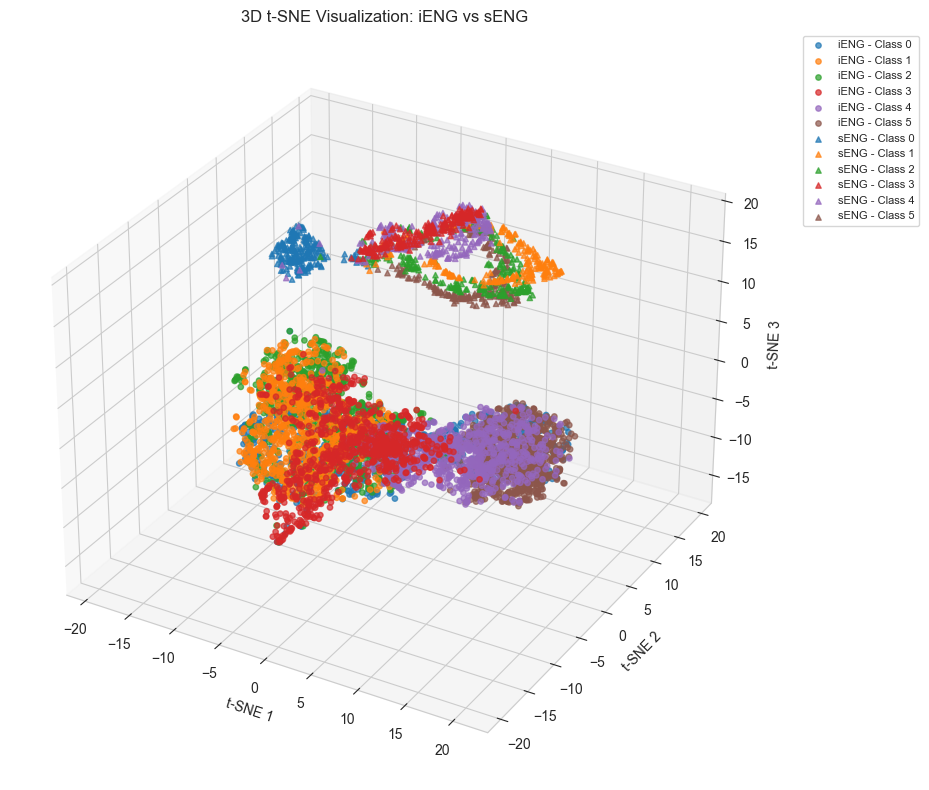

In [17]:
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

bluetooth_id = 'E9AD0E7DCC2B'
subject = 'Hunmin'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG, y_sENG = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=[0], balance=True)

X_iENG, y_iENG = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_iENG, y_iENG = shared_iENG_sENG.get_X_y(X_iENG, y_iENG, session=[0], balance=True)

###### iENG and sENG has different channels => 16 and 4; for iENG; randomly reduce it to 4.
selected_channels = np.random.choice(X_iENG.shape[1], size=4, replace=False)
X_iENG = X_iENG[:, selected_channels, :, :]

X_iENG_flat = X_iENG.reshape(X_iENG.shape[0], -1)
X_sENG_flat = X_sENG.reshape(X_sENG.shape[0], -1)


X_combined = np.concatenate([X_iENG_flat, X_sENG_flat], axis=0)
y_combined = np.concatenate([y_iENG, y_sENG], axis=0)
labels_modality = np.array(['iENG'] * X_iENG.shape[0] + ['sENG'] * X_sENG.shape[0])

#from sklearn.decomposition import PCA
#X_pca = PCA(n_components=50).fit_transform(X_combined)
#tsne = TSNE(n_components=3, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)

X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

markers = {'iENG': 'o', 'sENG': '^'}  # Different marker for each modality
colors = plt.cm.tab10.colors  # Up to 10 colors for classes

for modality in ['iENG', 'sENG']:
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[colors[cls]], marker=markers[modality],
            s=15, alpha=0.7,
            label=f"{modality} - Class {cls}"
        )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
plt.title("3D t-SNE Visualization: iENG vs sENG")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

bluetooth_id = 'E9AD0E7DCC2B'
subject = 'Hunmin'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG, y_sENG = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=[0], balance=True)

X_iENG, y_iENG = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_iENG, y_iENG = shared_iENG_sENG.get_X_y(X_iENG, y_iENG, session=[0], balance=True)

###### iENG and sENG has different channels => 16 and 4; for iENG; randomly reduce it to 4.
selected_channels = np.random.choice(X_iENG.shape[1], size=4, replace=False)
X_iENG = X_iENG[:, selected_channels, :, :]

X_iENG_flat = X_iENG.reshape(X_iENG.shape[0], -1)
X_sENG_flat = X_sENG.reshape(X_sENG.shape[0], -1)

X_combined = np.concatenate([X_iENG_flat, X_sENG_flat], axis=0)
y_combined = np.concatenate([y_iENG, y_sENG], axis=0)
labels_modality = np.array(['iENG'] * X_iENG.shape[0] + ['sENG'] * X_sENG.shape[0])

tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define two color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue

markers = {'iENG': 'o', 'sENG': '^'}

for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=12, alpha=0.5,
            label=f"{modality} - Class {cls}"
        )

# Remove all axes, labels, ticks, grid
ax.set_axis_off()

plt.title("3D t-SNE Visualization: iENG vs sENG", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

(8626, 4, 14, 1) (8626,)


In [ ]:
tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=12, alpha=0.6,
            label=f"{modality} - Class {cls}"
        )

# Remove all axes, ticks, labels, grid
ax.set_axis_off()

plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


(8626, 4, 14, 1) (8626,)


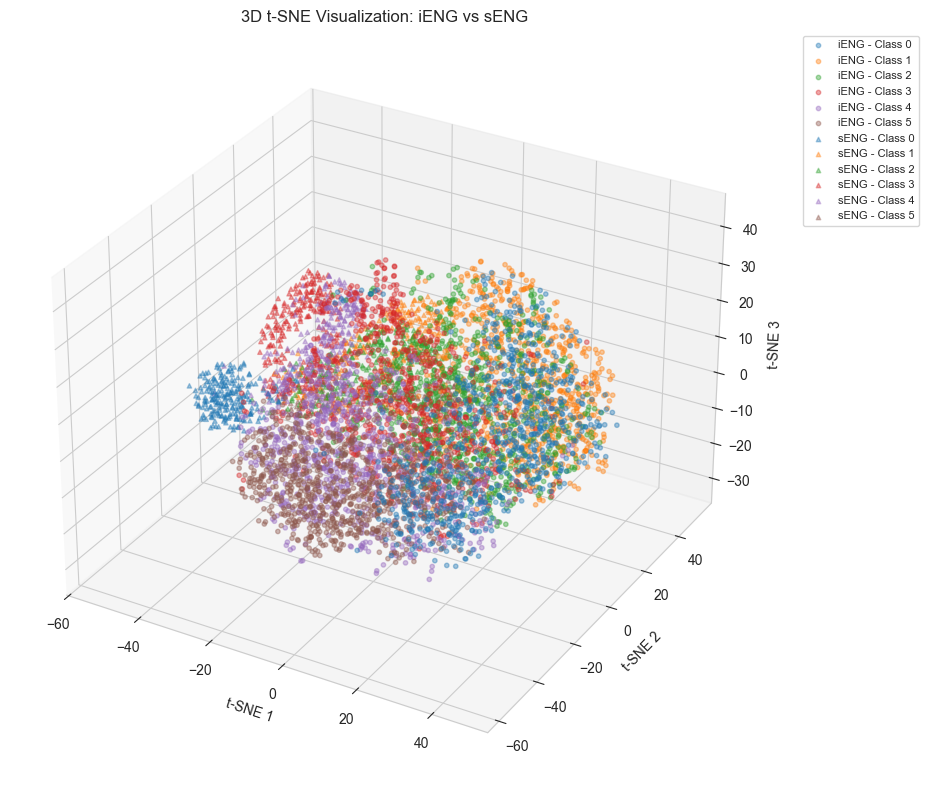

In [27]:
import umap.umap_ as umap

bluetooth_id = 'E9AD0E7DCC2B'
subject = 'Hunmin'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG, y_sENG = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'{subject}/{bluetooth_id}/raw/', num_session=[0], balance=True)

X_iENG, y_iENG = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_iENG, y_iENG = shared_iENG_sENG.get_X_y(X_iENG, y_iENG, session=[0], balance=True)

###### iENG and sENG has different channels => 16 and 4; for iENG; randomly reduce it to 4.
selected_channels = np.random.choice(X_iENG.shape[1], size=4, replace=False)
X_iENG = X_iENG[:, selected_channels, :, :]

X_iENG_flat = X_iENG.reshape(X_iENG.shape[0], -1)
X_sENG_flat = X_sENG.reshape(X_sENG.shape[0], -1)


X_combined = np.concatenate([X_iENG_flat, X_sENG_flat], axis=0)
y_combined = np.concatenate([y_iENG, y_sENG], axis=0)
labels_modality = np.array(['iENG'] * X_iENG.shape[0] + ['sENG'] * X_sENG.shape[0])

X_embedded = umap.UMAP(n_components=3, n_neighbors=50, min_dist=0.1, random_state=42).fit_transform(X_combined)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

markers = {'iENG': 'o', 'sENG': '^'}  # Different marker for each modality
colors = plt.cm.tab10.colors  # Up to 10 colors for classes

for modality in ['iENG', 'sENG']:
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[colors[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
plt.title("3D t-SNE Visualization: iENG vs sENG")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


# Heatmap

In [ ]:
H = pd.read_csv('results/subject_H_cross_validation_result_sENG-6class.csv')
B = pd.read_csv('results/subject_BY_cross_validation_result_sENG-6class.csv')
M = pd.read_csv('results/subject_MJ_cross_validation_result_sENG-6class.csv')

amp1 = pd.read_csv('results/Amputee-iENG-S2-cross-val-6class.csv')
amp2 = pd.read_csv('results/Amputee-iENG-S3-cross-val-6class.csv')

In [ ]:
cms = [H, B, M]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = shared_iENG_sENG.heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

In [ ]:
cms = [amp1, amp2]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = shared_iENG_sENG.heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

In [ ]:
# ---------------------------
# Example dummy data
# ---------------------------
# Suppose we have 5 gestures × 4 features, across 10 subjects
n_subjects = 10
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["RMS", "MNF", "Entropy", "Var"]

# Random example signals: shape = (subjects, gestures, features)
iENG = np.random.rand(n_subjects, len(gestures), len(features))
sENG = np.random.rand(n_subjects, len(gestures), len(features))

# ---------------------------
# Compute t-tests + effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

def cohens_d(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        t_stat, p_val = ttest_rel(iENG[:, j, i], sENG[:, j, i])
        p_values[i, j] = p_val
        effect_sizes[i, j] = cohens_d(iENG[:, j, i], sENG[:, j, i])

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Function to add stars based on p-value
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Create annotations (effect size + stars)
annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Plot heatmap
# ---------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df_effect, annot=annot, fmt="", cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (Effect Size + Significance)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

# ---------------------------
# Example dummy data
# ---------------------------
# Suppose we have 2 iENG subjects, 3 sENG subjects
# 5 gestures, 4 features
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["RMS", "MNF", "Entropy", "Var"]

# Data shapes: (subjects, gestures, features)
iENG = np.random.rand(2, len(gestures), len(features))
sENG = np.random.rand(3, len(gestures), len(features))

# ---------------------------
# Helper: Cohen's d for independent samples
# ---------------------------
def cohens_d_independent(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# ---------------------------
# Compute t-tests and effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        x = iENG[:, j, i]
        y = sENG[:, j, i]

        # Use independent t-test
        t_stat, p_val = ttest_ind(x, y, equal_var=False)  # Welch's t-test
        p_values[i, j] = p_val

        # Compute effect size
        effect_sizes[i, j] = cohens_d_independent(x, y)

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Significance stars
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Create annotation: effect size + stars
annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Heatmap plot
# ---------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df_effect, annot=annot, fmt='', cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (Independent Subjects)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ---------------------------
# Optional: violin + swarm plot for individual features
# ---------------------------
# Combine data for plotting
plot_data = []
for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        for val in iENG[:, j, i]:
            plot_data.append([gest, feat, 'iENG', val])
        for val in sENG[:, j, i]:
            plot_data.append([gest, feat, 'sENG', val])

df_plot = pd.DataFrame(plot_data, columns=['Gesture', 'Feature', 'Modality', 'Value'])

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_plot, x='Gesture', y='Value', hue='Modality', split=True, inner='quartile')
sns.swarmplot(data=df_plot, x='Gesture', y='Value', hue='Modality', dodge=True, color='k', alpha=0.7)
plt.title("Feature distributions for iENG vs sENG")
plt.ylabel("Feature value")
plt.legend(title='Modality')
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------
# Example dummy data
# ---------------------------
# 2 iENG subjects, 3 sENG subjects, 5 gestures, 14 features
gestures = ["G1", "G2", "G3", "G4", "G5"]
features = ["MAV", "WL", "ZC", "SSC", "VAR", "RMS", "IEMG", "MNF",
            "MDF", "WAMP", "ZC_rate", "AR_coef", "Hjorth_Activity", "Entropy"]

# Random data shape: (subjects, gestures, features)
iENG = np.random.rand(2, len(gestures), len(features))
sENG = np.random.rand(3, len(gestures), len(features))

# ---------------------------
# Helper: Cohen's d for independent samples
# ---------------------------
def cohens_d_independent(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# ---------------------------
# Compute t-tests and effect sizes
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        x = iENG[:, j, i]
        y = sENG[:, j, i]

        # Independent t-test (Welch)
        t_stat, p_val = ttest_ind(x, y, equal_var=False)
        p_values[i, j] = p_val

        # Cohen's d
        effect_sizes[i, j] = cohens_d_independent(x, y)

# ---------------------------
# Convert to DataFrame for plotting
# ---------------------------
df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# ---------------------------
# Significance stars
# ---------------------------
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        star = significance_stars(df_pval.iloc[i, j])
        annot.iloc[i, j] = annot.iloc[i, j] + star

# ---------------------------
# Heatmap
# ---------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(df_effect, annot=annot, fmt='', cmap="coolwarm", center=0,
            cbar_kws={'label': "Cohen's d (effect size)"})
plt.title("iENG vs. sENG Comparison (All 14 Features × Gestures)")
plt.xlabel("Gestures")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ---------------------------
# Violin + Swarm plots for all features
# ---------------------------
plot_data = []
for i, feat in enumerate(features):
    for j, gest in enumerate(gestures):
        for val in iENG[:, j, i]:
            plot_data.append([gest, feat, 'iENG', val])
        for val in sENG[:, j, i]:
            plot_data.append([gest, feat, 'sENG', val])

df_plot = pd.DataFrame(plot_data, columns=['Gesture', 'Feature', 'Modality', 'Value'])

# Faceted violin plot using seaborn's FacetGrid
g = sns.FacetGrid(df_plot, col="Feature", col_wrap=4, sharey=False, height=3.5)
g.map_dataframe(sns.violinplot, x="Gesture", y="Value", hue="Modality", split=True, inner="quartile", palette=["lightblue","lightcoral"])
g.map_dataframe(sns.swarmplot, x="Gesture", y="Value", hue="Modality", dodge=True, color='k', alpha=0.6)

# Remove duplicate legends
for ax in g.axes.flatten():
    ax.legend_.remove()
g.add_legend(title="Modality")
plt.tight_layout()
plt.show()
